# Data 620 Week 3 Assignment - Graph Visualization
### Author: Pedro P Gatica Jr

## Introduction

#### Source:  I am analyzing the Facebook ego network dataset from the SNAP: Network Datasets https://snap.stanford.edu/data/ego-Facebook.html Created by J. McAuley and J. Leskovec. 2012.

#### This dataset consists of 'circles' (or 'friends lists') from Facebook. Facebook data was collected from survey participants using this Facebook app. The dataset includes node features (profiles), circles, and ego networks.

In [3]:
import io
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import random
import requests
import scipy as sp
import pickle
import csv

In [5]:
G = nx.read_edgelist("/Users/Audiorunner13/CUNY MSDS Course Work/Data620 Fall 2026/Week 3/facebook_combined.txt", delimiter=" ", nodetype=int)

In [6]:
print(G)

Graph with 4039 nodes and 88234 edges


In [7]:
print(G.number_of_nodes(), "nodes")

4039 nodes


In [8]:
print(G.number_of_edges(), "edges")

88234 edges


# Analysis

In [9]:
# nx.diameter() does all-pairs BFS under the hood. If you also want
# other distance stats, compute eccentricities once and reuse them:
ecc = nx.eccentricity(G)          # dict: node -> max distance to any other node
diameter = max(ecc.values())
radius = min(ecc.values())
print(f"Diameter: {diameter}, Radius: {radius}")

Diameter: 8, Radius: 4


In [10]:
# Average shortest path length (a common companion stat to diameter)
avg_path_len = nx.average_shortest_path_length(G)
print(f"Average shortest path length: {avg_path_len:.3f}")

Average shortest path length: 3.693


In [11]:
# --- Graph distance between specific nodes ---
u = 0
v = 100
dist = nx.shortest_path_length(G, source=u, target=v)
path = nx.shortest_path(G, source=u, target=v)
print(f"Distance between {u} and {v}: {dist}")
print(f"Path: {path}")

Distance between 0 and 100: 1
Path: [0, 100]


### The network has a Diameter of 8 and a radius of 4.
#### The diameter measures the longest shortest path between any two nodes in the graph or that even the furthest connected people in this network are connected by no more than 8 nodes.  
#### The radius of 4 measures the longest shortest path of at least one center node in the network can be reached in 4 hops or fewer.  This node may be the most well connected node.
#### The average shortest path length of 3.693 means that on average, you can get from any person to any other person in the network through an average of 3.693 hops.
#### Nodes 0 and 100 connected by one edge which means that they are immediate friends.

In [12]:
# --- Full distance distribution (useful for understanding "small world" structure) ---
from collections import Counter
dist_counts = Counter()
for source in G.nodes():
    lengths = nx.single_source_shortest_path_length(G, source)
    dist_counts.update(lengths.values())

for d in sorted(dist_counts):
    print(f"distance {d}: {dist_counts[d]} pairs")

distance 0: 4039 pairs
distance 1: 176468 pairs
distance 2: 2716134 pairs
distance 3: 3981852 pairs
distance 4: 5861560 pairs
distance 5: 2565170 pairs
distance 6: 677214 pairs
distance 7: 315464 pairs
distance 8: 15620 pairs


In [13]:
d = dict((x,G.neighbors(x)) for x in G.nodes())
g = nx.Graph(d)

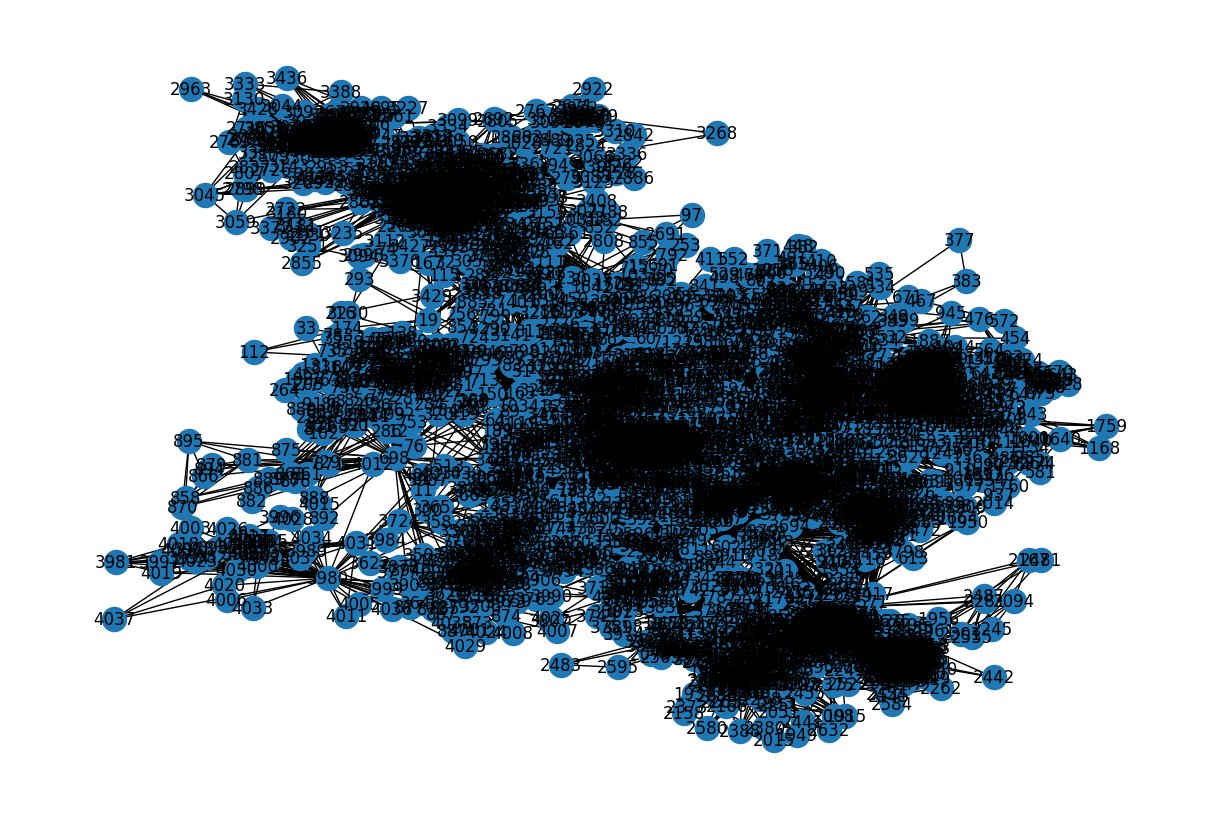

In [15]:
plt.figure(figsize=(12,8))
nx.draw(g, with_labels=True)
plt.show()

#### This is a very dense netwoork and you can see many dense clusters. There are most likely many brokers/brdiges between the clusters.  I also do not see any isolated nodes.

In [17]:
def bfs_subset(G, start_node, target_nodes=300):
    visited = {start_node}
    queue = [start_node]
    while queue and len(visited) < target_nodes:
        node = queue.pop(0)
        neighbors = list(G.neighbors(node))
        random.shuffle(neighbors)
        for n in neighbors:
            if n not in visited:
                visited.add(n)
                queue.append(n)
                if len(visited) >= target_nodes:
                    break
    return list(visited)

# Note:  
### Disable only if you want to randomly select another set of nodes otherwise leave as a Markdown Cell

start = random.choice(list(G.nodes))
subset = bfs_subset(G, start, target_nodes=200)

I = G.subgraph(subset)

###  Write the subgraph to a file to keep selected nodes and edges
with open("/Users/Audiorunner13/CUNY MSDS Course Work/Data620 Fall 2026/Week 3/subset_edges.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["source", "target"])
    for u, v in I.edges():
        writer.writerow([u, v])

In [29]:
I = nx.Graph()
with open("/Users/Audiorunner13/CUNY MSDS Course Work/Data620 Fall 2026/Week 3/subset_edges.csv") as f:
    reader = csv.reader(f)
    next(reader)  # skip header
    for u, v in reader:
        I.add_edge(u, v)

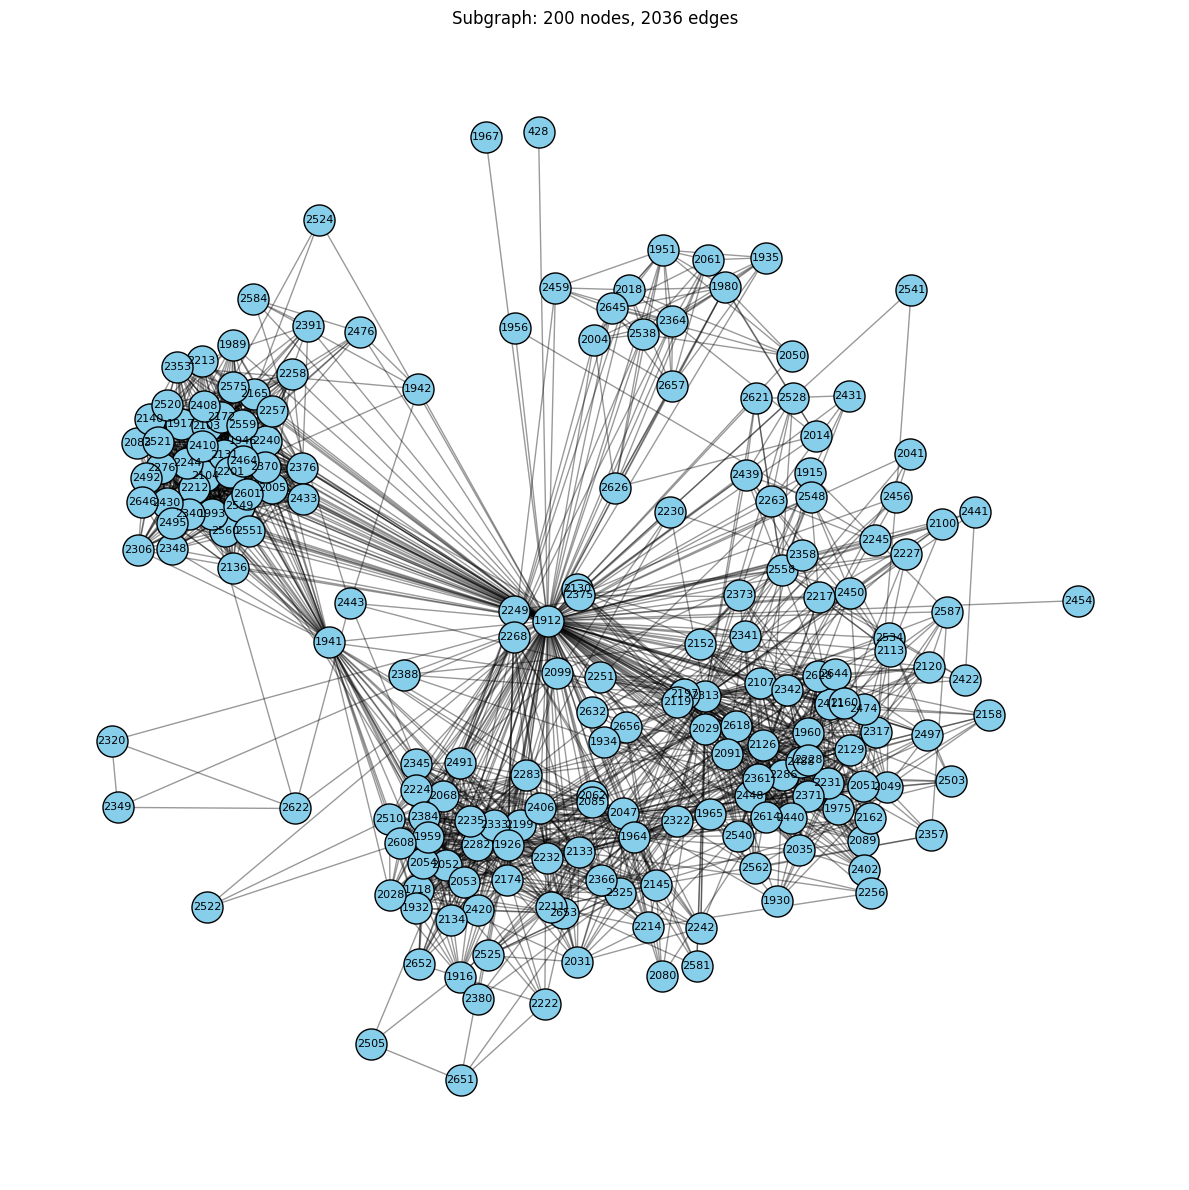

In [30]:
plt.figure(figsize=(12, 12))

# spring_layout is the usual default — spaces nodes out based on connectivity
pos = nx.spring_layout(I, seed=42, k=0.5)  # k = spacing between nodes, tweak if crowded

nx.draw_networkx_nodes(I, pos, node_size=500, node_color="skyblue", edgecolors="black")
nx.draw_networkx_edges(I, pos, alpha=0.4)
nx.draw_networkx_labels(I, pos, font_size=8)

plt.title(f"Subgraph: {I.number_of_nodes()} nodes, {I.number_of_edges()} edges")
plt.axis("off")
plt.tight_layout()
plt.show()

### As you can see from the Subgraph, there appears to be a broker/bridge at node 1912 with two, possibly three communities of Facebook friends.  We will calculate centrality measures of degree, betweenness, closeness, Eigenvector, and pagerank.

### Degree centrality
#### Measures the number of direct connections(edges) a node has, relative to the maximum possible number of connections in the graph. A node with high degree centrality is a highly connected node ("popular").

In [20]:
degree_cent = nx.degree_centrality(I)

### Betweenness Centrality 
#### Measures how often a node lies on the shortest path between other pairs of nodes in the network.  A node with high betweenness acts as a bridge or broker.

In [21]:
# normalized=True scales values to [0,1]; set False for raw counts
betweenness_cent = nx.betweenness_centrality(I, normalized=True)

### Closeness Centrality 
#### Measures how close a node is to all other nodes in the network, based on the shortest path distances. High closeness can reach other nodes quickly.

In [22]:
closeness_cent = nx.closeness_centrality(I)

### Eigenvector Centrality 
#### Measures a node's importance based on how many connections it has and how important its neighbors are.

In [23]:
eigenvector_cent = nx.eigenvector_centrality(I, max_iter=1000)

### Page Rank
#### A variant of eigenvector centrality which was originally built for ranking web pages, Itr measures node importance based on both the quantity and quality of incoming connections

In [24]:
pagerank_cent = nx.pagerank(I, alpha=0.85)  # alpha = damping parameter

#### Build a table displaying the top ten nodes with the most centrality.

In [25]:
centrality_df = pd.DataFrame({
    'degree': degree_cent,
    'betweenness': betweenness_cent,
    'closeness': closeness_cent,
    'eigenvector': eigenvector_cent,
    'pagerank': pagerank_cent
})

# Sort by whichever measure you care about most, e.g. degree
centrality_df = centrality_df.sort_values('degree', ascending=False)

print(centrality_df.head(10))  # top 10 most central nodes


        degree  betweenness  closeness  eigenvector  pagerank
1912  1.000000     0.703854   1.000000     0.252743  0.052959
2313  0.427136     0.057583   0.635783     0.058917  0.023239
2047  0.281407     0.016240   0.581871     0.050644  0.013213
1941  0.246231     0.014356   0.570201     0.139393  0.009294
2244  0.221106     0.000890   0.562147     0.173041  0.007562
1964  0.221106     0.009153   0.562147     0.040855  0.011026
1993  0.216080     0.001613   0.560563     0.168923  0.007625
2410  0.216080     0.000904   0.560563     0.170817  0.007422
2464  0.211055     0.000568   0.558989     0.169362  0.007187
2240  0.211055     0.000958   0.558989     0.166737  0.007318


### What can we surmise from the subgraph and the table of centralities?

#### Node 1912 is the dominant node in this subset of nodes.
#### 1. Degree = 1.0 means or at least appears that this node is connected to every other node in the subgraph.
#### 2. Betweenness = 0.704. 70% of the shortest paths between other node pairs pass through this node. This is high and it means that 1912 acts as an important bridge/broker connecting different parts of the network. What would happen if wew removed node 1912.
#### 3. Closeness = 1.0 means that this node can raachevery other node in the minimum number of hops.
#### 4. Eigenvector = 0.253.  This is low which means that it is not connnected to important neighbors.
#### 5. PageRank = 0.053 

### In Summary

#### The Subgrah is a hub and cluster topology.
#### 1. Node 1912 is a super-hub due to the high degree, high closeness, and a closeness of 1.  This would be the ego node of the ego-network subset.
#### 2. There are two, possibly three, clusters (communities) tied to node 1912 and maybe similar to it.